In [1]:
import pickle
import os, sys
import numpy as np
import pandas as pd
from pathlib import Path
from time import process_time
from collections import defaultdict

from prod_fs import ProD

fidx = 5

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=250, n_features=20, n_classes=5, weights=[0.1, 0.2, 0.3, 0.25, 0.15], n_informative=5, random_state=0
)
y

array([3, 2, 3, 2, 3, 3, 3, 1, 3, 4, 3, 1, 2, 2, 2, 0, 1, 3, 2, 3, 0, 4,
       1, 1, 3, 3, 2, 1, 3, 4, 2, 2, 4, 3, 2, 2, 2, 2, 4, 2, 1, 4, 4, 3,
       4, 3, 4, 1, 3, 3, 2, 0, 1, 2, 2, 2, 2, 1, 1, 1, 3, 0, 3, 2, 4, 1,
       0, 2, 1, 3, 3, 2, 1, 2, 2, 1, 3, 2, 3, 2, 0, 4, 1, 4, 0, 0, 3, 1,
       3, 0, 0, 2, 4, 1, 3, 1, 1, 3, 2, 0, 3, 3, 4, 3, 3, 1, 3, 4, 2, 3,
       4, 2, 3, 3, 4, 4, 1, 2, 2, 2, 2, 2, 2, 1, 4, 1, 2, 3, 2, 2, 3, 2,
       2, 1, 4, 1, 0, 1, 3, 2, 0, 1, 3, 4, 2, 4, 4, 0, 4, 2, 2, 0, 2, 3,
       2, 1, 0, 3, 1, 4, 4, 2, 0, 2, 1, 4, 0, 1, 3, 1, 0, 3, 2, 2, 0, 3,
       2, 4, 1, 3, 3, 4, 3, 2, 1, 3, 2, 3, 2, 1, 1, 2, 3, 3, 2, 2, 3, 3,
       1, 4, 2, 3, 2, 4, 1, 3, 3, 1, 1, 3, 0, 2, 0, 4, 2, 1, 1, 0, 4, 4,
       2, 2, 0, 1, 3, 0, 2, 1, 1, 3, 2, 1, 2, 2, 1, 2, 0, 3, 1, 4, 3, 2,
       4, 1, 4, 2, 2, 2, 3, 2])

In [3]:
mapping = {0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e'}
y = np.array([mapping[y] for y in y])
y

array(['d', 'c', 'd', 'c', 'd', 'd', 'd', 'b', 'd', 'e', 'd', 'b', 'c',
       'c', 'c', 'a', 'b', 'd', 'c', 'd', 'a', 'e', 'b', 'b', 'd', 'd',
       'c', 'b', 'd', 'e', 'c', 'c', 'e', 'd', 'c', 'c', 'c', 'c', 'e',
       'c', 'b', 'e', 'e', 'd', 'e', 'd', 'e', 'b', 'd', 'd', 'c', 'a',
       'b', 'c', 'c', 'c', 'c', 'b', 'b', 'b', 'd', 'a', 'd', 'c', 'e',
       'b', 'a', 'c', 'b', 'd', 'd', 'c', 'b', 'c', 'c', 'b', 'd', 'c',
       'd', 'c', 'a', 'e', 'b', 'e', 'a', 'a', 'd', 'b', 'd', 'a', 'a',
       'c', 'e', 'b', 'd', 'b', 'b', 'd', 'c', 'a', 'd', 'd', 'e', 'd',
       'd', 'b', 'd', 'e', 'c', 'd', 'e', 'c', 'd', 'd', 'e', 'e', 'b',
       'c', 'c', 'c', 'c', 'c', 'c', 'b', 'e', 'b', 'c', 'd', 'c', 'c',
       'd', 'c', 'c', 'b', 'e', 'b', 'a', 'b', 'd', 'c', 'a', 'b', 'd',
       'e', 'c', 'e', 'e', 'a', 'e', 'c', 'c', 'a', 'c', 'd', 'c', 'b',
       'a', 'd', 'b', 'e', 'e', 'c', 'a', 'c', 'b', 'e', 'a', 'b', 'd',
       'b', 'a', 'd', 'c', 'c', 'a', 'd', 'c', 'e', 'b', 'd', 'd

## ProD with unweighted averaging scheme

In [4]:
prodRankerMean = ProD(
    integration_method="trapz", delta=500, bw_method="scott",
    k=2, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5,
    averaging_method="mean"
)
prodRankerMean.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'mean'


Averaging scheme: mean
Computing pairwise intersection areas ...


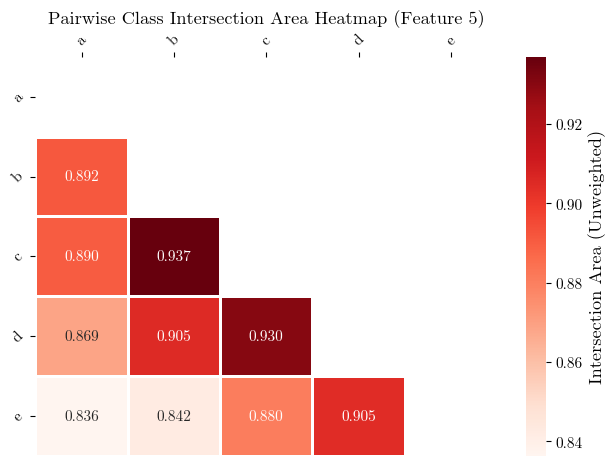

In [5]:
from matplotlib import rc
import matplotlib.pyplot as plt
plt.rcParams['font.serif'] = ['CMU Serif']
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'
plt.rcParams['font.size'] = 11

fig, ax = plt.subplots(1, 1)
prodRankerMean.plot_classPairHeatmaps(fidx, _ax=ax)
plt.show()

## ProD with weighted averaging scheme

In [6]:
prodRankerWeighted = ProD(
    integration_method="trapz", delta=500, bw_method="scott",
    k=2, n_jobs=-1, mode="release", lower_end=-1.5, upper_end=2.5,
    averaging_method="weighted"
)
prodRankerWeighted.fit(X, y)

Constructing and evaluating the KDEs per class for every feature ... 
 - Kernels constructed!
Computing intersection areas ...
 - averaging_method: 'weighted'


Averaging scheme: weighted
Computing pairwise intersection areas ...
 - averaging_method: 'weighted'


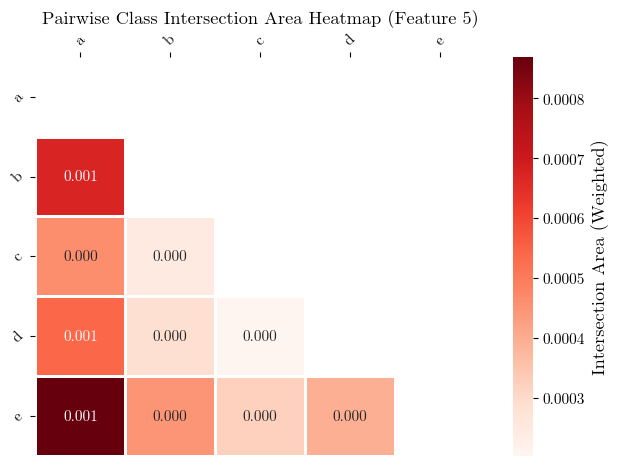

In [7]:
fig, ax = plt.subplots(1, 1)
prodRankerWeighted.plot_classPairHeatmaps(fidx, _ax=ax)
plt.show()